In [74]:
import random
import math
import numpy as np
import copy
import matplotlib.pyplot as plt

def print_matrix(M):
    for row in M:
        row_rounded = [round(x, 2) for x in row]
        row_no_negative_zeros = [0.0 if math.isclose(x, 0.0) else x for x in row_rounded]
        print(" ".join(f"{x:.2f}" for x in row_no_negative_zeros))
    print()


def divide_row(row, k, M):
    n = len(M)
    for j in range(n):
        M[row][j] /= k


def swap_rows(row1, row2, M):
    n = len(M)
    for j in range(n):
        M[row1][j], M[row2][j] = M[row2][j], M[row1][j]


def add_scaled_row_to_another(row1, row2, k, M):
    n = len(M)
    for j in range(n):
        M[row2][j] += M[row1][j] * k


def gauss_elimination(M, pivoting = True, normalize = True):
    n = len(M)

    for j in range(n): 
        if pivoting:
            maxi, pivot_idx = 0.0, 0
            for i in range(j, n):
                if abs(M[i][j]) > maxi :
                    maxi, pivot_idx = abs(M[i][j]), i
            if pivot_idx != j: # we need to swap
                swap_rows(j, pivot_idx, M)
        if normalize:
            divide_row(j, M[j][j], M) # we want our row to have 1.0 as the element on the diagonal

        for k in range(j + 1, n):
            assert not np.isclose(M[j][j], 0)
            add_scaled_row_to_another(j, k, -M[k][j]/M[j][j], M) 


def inverse_matrix(M):
    n = len(M)
    M_res = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        M_res[i][i] = 1
    
    for j in range(n):
        maxi, pivot_idx = 0.0, 0 
        for i in range(j, n):
            if abs(M[i][j]) > maxi :
                maxi, pivot_idx = abs(M[i][j]), i 

        if pivot_idx != j:
            swap_rows(j, pivot_idx, M)
            swap_rows(j, pivot_idx, M_res)

        div = M[j][j]
        divide_row(j, div, M) 
        divide_row(j, div, M_res)

        for k in range(n):
            if k != j:
                scalar = -M[k][j]
                add_scaled_row_to_another(j, k, scalar, M) 
                add_scaled_row_to_another(j, k, scalar, M_res)

    return M_res



n = 6
M1 = [[random.randint(0, 15) for _ in range(n)] for _ in range(n)]
M2 = copy.deepcopy(M1)


print()
print_matrix(M1)
print("\nAFTER GAUSS ELIMINATION:\n")
gauss_elimination(M1)
print_matrix(M1)


if np.linalg.det(np.array(M2)) != 0:
    print("\nINVERSE MATRIX\n")
    print_matrix(inverse_matrix(M2))


7.00 13.00 2.00 9.00 6.00 15.00
10.00 15.00 10.00 15.00 2.00 12.00
3.00 12.00 14.00 12.00 12.00 13.00
14.00 14.00 3.00 5.00 7.00 6.00
11.00 14.00 5.00 3.00 5.00 13.00
6.00 0.00 7.00 6.00 11.00 12.00


AFTER GAUSS ELIMINATION:

1.00 1.00 0.21 0.36 0.50 0.43
0.00 1.00 1.48 1.21 1.17 1.30
0.00 0.00 1.00 0.76 1.03 1.18
0.00 0.00 0.00 1.00 0.73 2.51
0.00 0.00 0.00 0.00 1.00 0.92
0.00 0.00 0.00 0.00 0.00 1.00


INVERSE MATRIX

-0.05 0.04 -0.07 0.05 0.01 0.06
0.02 -0.03 0.05 0.02 0.02 -0.08
-0.12 0.04 0.04 -0.04 0.08 0.01
0.06 0.05 -0.02 0.03 -0.13 0.01
0.03 -0.08 0.05 0.07 -0.06 0.01
0.04 0.00 -0.03 -0.08 0.07 0.03



In [75]:
def gauss_numpy(A, pivoting = True, normalize = True, b = None):
    n = len(A)
    A = np.array(A, dtype=np.float64)
    if b is not None:
        b = np.array(b, dtype=np.float64)

    for i in range(n):
        if pivoting or np.isclose(A[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(A[i:, i]))
            else:
                try:
                    pivot_idx = i + np.where(~np.isclose(np.abs(A[i:, i]), 0.0))[0][0]
                except IndexError:
                    print("No nonzero found in column\n", A[i:, i])
            
            if pivot_idx != i:
                A[[i, pivot_idx]] = A[[pivot_idx, i]]
                if b is not None:
                    b[i], b[pivot_idx] = b[pivot_idx], b[i]

        assert not np.isclose(A[i, i], 0.0)

        if normalize:
            pivot_val = A[i, i]
            A[i, :] /= pivot_val
            if b is not None:
                b[i] /= pivot_val

        for j in range(i+1, n):
            factor = A[j][i]/A[i, i]
            A[j, :] -= factor * A[i, :]
            if b is not None:
                b[j] -= factor * b[i]
    return A, b


def back_substitution(U:np.ndarray, b:np.ndarray):
    x = np.zeros_like(b)
    nn = U.shape[0]
    for i in range(nn-1, -1, -1):
        x[i] = (b[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x


def lu_factorization(A, pivoting = True):
    n = len(A)
    P = [i for i in range(n)]
    A = np.array(A, dtype=np.float32)
    L, U = np.array([[0.0 for _ in range(n)] for _ in range(n)]), np.copy(A)
    for i in range(n):
        L[i, i] = 1.0
    for i in range(n):
        
        if pivoting or np.isclose(U[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(U[i:, i]))
            else:
                pivot_idx = i + np.where(~np.isclose(np.abs(U[i:, i]), 0.0))[0][0]
        
            if pivot_idx != i:
                U[[i, pivot_idx]] = U[[pivot_idx, i]]
                L[[i, pivot_idx], :i] = L[[pivot_idx, i], :i]
                P[i], P[pivot_idx] = P[pivot_idx], P[i]

            assert not np.isclose(U[i, i], 0.0)

        for j in range(i+1, n):
            factor = U[j][i]/U[i, i]
            U[j, :] -= factor * U[i, :]
            L[j, i] = factor

    P = np.array(P)
    P_res = np.zeros((P.size, P.max() + 1))
    P_res[np.arange(P.size), P] = 1
    return P_res, L , U


def assert_is_close(P, L, U, A):
    A1 = np.transpose(P) @ L @ U
    diff = np.abs(A1 - A)
    return np.allclose(P @ A, L @ U), diff


def assert_l_matrix(L, tol):
    identity = np.eye(L.shape[0])
    L_tr = np.triu(L) # eliminates nonzero elements of upper diagonal part
    assert np.allclose(L_tr - identity, np.zeros_like(L), atol = tol) # checks ones on diagonal


def assert_u_matrix(U, tol, has_ones = False):
    U_tr = np.tril(U, (-1 if not has_ones else 0) )
    if has_ones:
        U_tr -= np.eye(U.shape[0])
    assert np.allclose(U_tr, 0, atol=tol)


In [91]:
NUM_TRIALS = 10000
n = 40

pivot_diff = []
with_error, without_error = 0, 0
for i in range(NUM_TRIALS):
    if i % (NUM_TRIALS//50) == 0:
        print(i, end = ' ')
    M3 = [[random.random() * 10 for _ in range(n)] for _ in range(n)]
    M3 = np.array(M3)
    P2, L2, U2 = lu_factorization(M3)
    P3, L3, U3 = lu_factorization(M3, False)

    for j, (Lj, Uj, tol) in enumerate([[L2, U2, 2e-6], [L3, U3, 5e-3]]):
        try:
            assert_l_matrix(Lj, tol)
            assert_u_matrix(Uj, tol)
        except Exception as e:
            if j == 0:
                with_error += 1
            else:
                without_error += 1

    
    pivot, no_pivot = np.max(np.abs((P2 @ M3 - L2 @ U2))), np.max(np.abs((P3 @ M3 - L3 @ U3)))
    diff_i = no_pivot/pivot
    pivot_diff.append([no_pivot, pivot, diff_i])
    

pivot_diff = np.array(pivot_diff)

0 200 400 600 800 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200 3400 3600 3800 4000 4200 4400 4600 4800 5000 5200 5400 5600 5800 6000 6200 6400 6600 6800 7000 7200 7400 7600 7800 8000 8200 8400 8600 8800 9000 9200 9400 9600 9800 

In [92]:
print(f"Outside the tolerance: pivot = {with_error}/{NUM_TRIALS}, no_pivot = {without_error}/{NUM_TRIALS}")

Outside the tolerance: pivot = 966/10000, no_pivot = 1098/10000


Lims: (0, 265.94)
Median no pivot: 0.00016206417052799793
Median with pivot 3.768478626153815e-06
Max difference: 519795


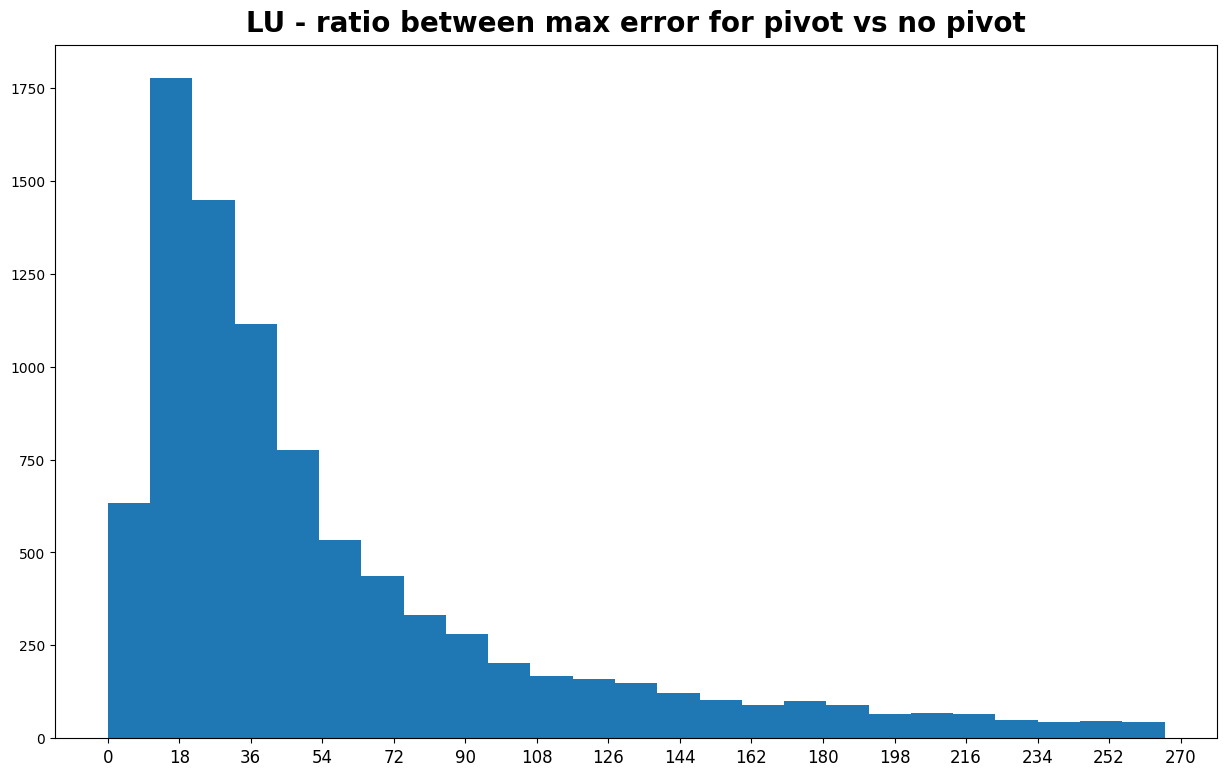

In [93]:
lims = [0, np.percentile(pivot_diff[:, 2], 89)]
k = 25
s = 15

print(f"Lims: ({lims[0]}, {round(lims[1], 2)})")

plt.figure(figsize=(15, 9))
plt.hist(pivot_diff[:, 2], bins=[lims[1]/k * i for i in range(k+1)])
plt.xticks([round(lims[1]/s) * i for i in range(s+1)], fontsize = 12)

plt.title("LU - ratio between max error for pivot vs no pivot", fontsize=20, fontweight='bold', pad=10 )

print("Median no pivot:", np.median(pivot_diff[:, 0]))
print("Median with pivot", np.median(pivot_diff[:, 1]))

idx_max = np.argmax(pivot_diff[:, 2])

print("Max difference:", round(np.max(pivot_diff[:, 2])))

In [103]:
NUM_TRIALS = 10000
gauss_with, gauss_without = 0, 0
gauss_pivot_diff = []
n = 40
for i in range(NUM_TRIALS):

    A = np.array([[random.random() * 15 for _ in range(n)] for _ in range(n)])
    x = np.array([random.random() * 100 for _ in range(n)])
    b = np.dot(A, x)

    U1, b1 = gauss_numpy(A, pivoting=False, b = b)
    x_without = back_substitution(U1, b1)
    no_pivot = np.max(np.abs(x_without - x))
    if i % (NUM_TRIALS//50) == 0:
        print(i, end = ' ')


    U2, b2 = gauss_numpy(A, pivoting=True, b = b)
    x_with = back_substitution(U2, b2)
    pivot = np.max(np.abs(x_with - x))

    gauss_pivot_diff.append([no_pivot, pivot, no_pivot/pivot])
    

0 200 400 600 800 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200 3400 3600 3800 4000 4200 4400 4600 4800 5000 5200 5400 5600 5800 6000 6200 6400 6600 6800 7000 7200 7400 7600 7800 8000 8200 8400 8600 8800 9000 9200 9400 9600 9800 

In [104]:
gauss_pivot_diff = np.array(gauss_pivot_diff)


Lims: (0, 104.05)
Median no pivot: 2.580513580596744e-11
Median with pivot 1.4206413823103503e-12


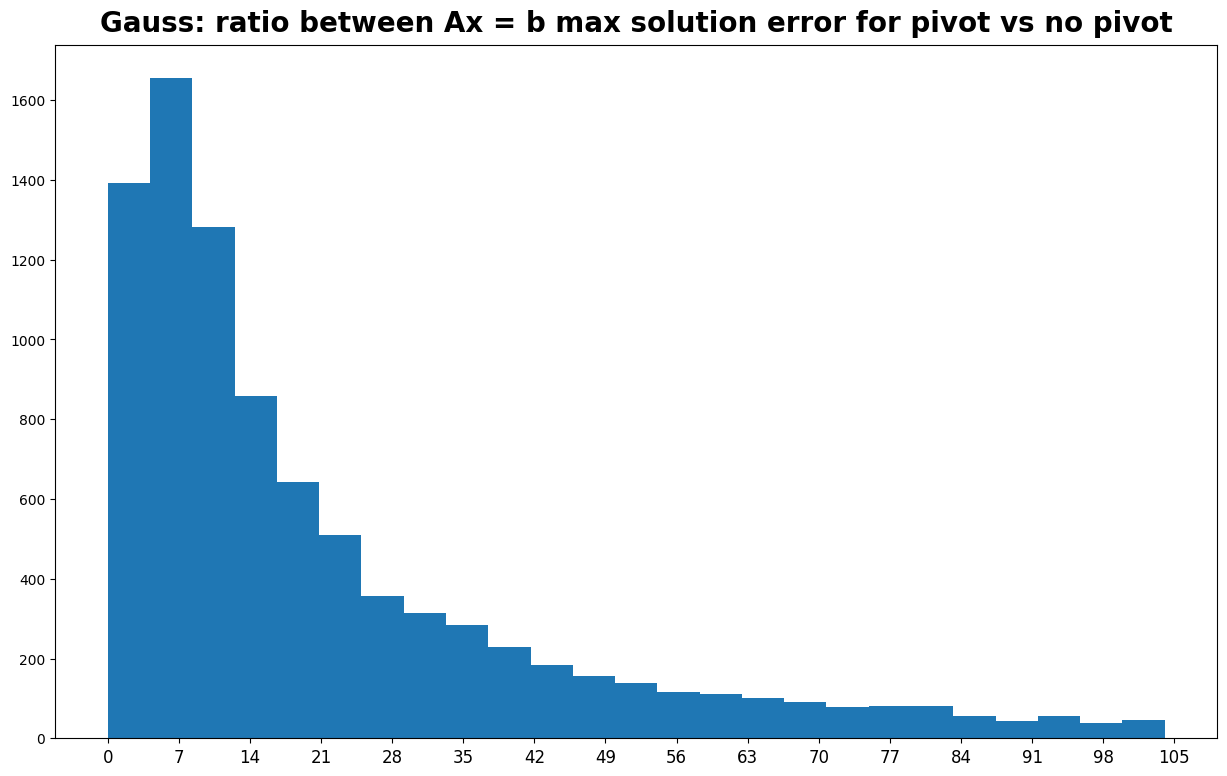

In [105]:
gauss_lims = [0, np.percentile(gauss_pivot_diff[:, 2], 89)]
k = 25
s = 15

print(f"Lims: ({gauss_lims[0]}, {round(gauss_lims[1], 2)})")

plt.figure(figsize=(15, 9))
plt.hist(gauss_pivot_diff[:, 2], bins=[gauss_lims[1]/k * i for i in range(k+1)])
plt.xticks([round(gauss_lims[1]/s) * i for i in range(s+1)], fontsize = 12)
plt.title("Gauss: ratio between Ax = b max solution error for pivot vs no pivot", fontsize=20, fontweight='bold', pad=10 )

print("Median no pivot:", np.median(gauss_pivot_diff[:, 0]))
print("Median with pivot", np.median(gauss_pivot_diff[:, 1]))

### Example tests

In [117]:
A = np.array([[random.random() * 20 for _ in range(5)] for _ in range(5)])
x = np.array([random.random() * 50 for _ in range(5)])
b = np.dot(A, x)
print("b:\n", b, sep = '')
U2, b2 = gauss_numpy(A, pivoting = False, b = b)
print("Diagonal Gauss:", U2.diagonal())
print("b2:\n", b2, sep='')
x2 = back_substitution(U2, b2)
print("x:\n", x, sep = '')
print("x_solved:\n",x2, sep = '')


b:
[ 403.5203496   297.50841203  713.79648214 1046.67051566  240.08385005]
Diagonal Gauss: [1. 1. 1. 1. 1.]
b2:
[ 128.6330348  -234.4386698   870.31159186  263.81724959   40.88162609]
x:
[25.03415004  3.31298314  3.95488463  2.85974262 40.88162609]
x_solved:
[25.03415004  3.31298314  3.95488463  2.85974262 40.88162609]
